In [1]:
from framework import FrameWork
from framework import AveragedPerdiction
from framework import BorexinoRecoilSpectrum

import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['text.usetex']=True
plt.style.use('classic')

frame           = FrameWork(m12_nuisance=False)
dr_dldt         = frame[[30.4,0]] #theta_12 from global analsys

pred_bo,_ = AveragedPerdiction(dr_dldt,frame)


elrec_be70 = BorexinoRecoilSpectrum(dr_dldt[0]['Be7'][0],frame.t_e['Be7'][0],frame.year,frame.theta)
elrec_be71 = BorexinoRecoilSpectrum(dr_dldt[0]['Be7'][1],frame.t_e['Be7'][1],frame.year,frame.theta)
elrec_pp   = BorexinoRecoilSpectrum(dr_dldt[0]['pp'][0],frame.t_e['pp'][0],frame.year,frame.theta)
elrec_pep  = BorexinoRecoilSpectrum(dr_dldt[0]['pep'][0],frame.t_e['pep'][0],frame.year,frame.theta)
elrec_B8   = BorexinoRecoilSpectrum(dr_dldt[0]['B8'][0],frame.t_e['B8'][0],frame.year,frame.theta)

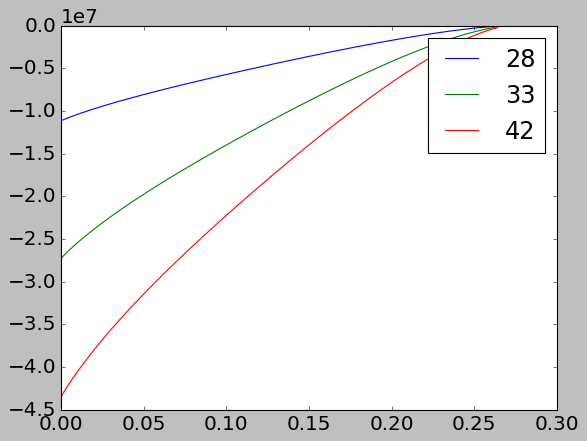

In [33]:
angle = [28,33,42]
frame0           = FrameWork(m12_nuisance=False)
dr_dldt0         = frame0[[25,0]]
print()
for i in angle:
    #print(i,dr_dldt[0]['B8'][0][0] - dr_dldt0[0]['B8'][0][0])
    dr_dldt         = frame[[i,0]]
    plt.plot(frame.t_e['pp'][0],dr_dldt[0]['pp'][0][0] - dr_dldt0[0]['pp'][0][0],label=str(i))
plt.legend()

In [2]:
print(pred_bo)

[[143.33904079  50.45634012   2.88331119]]


In [3]:
print(np.trapz((elrec_be70+elrec_be71)[60:339]))

22.57300049129734


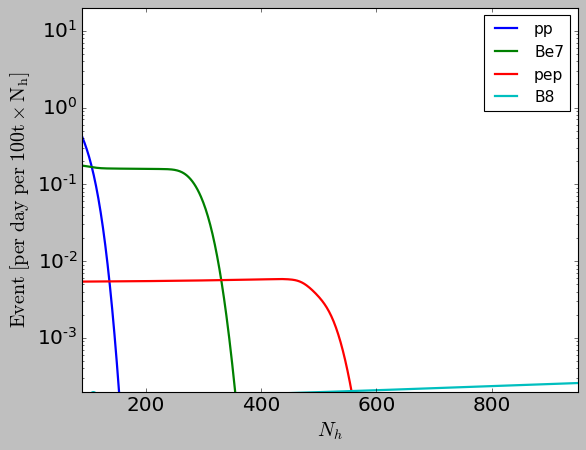

In [4]:
plt.rcParams.update({'font.size': 18})
plt.ylim(2e-4,20)
plt.yscale('log')
plt.xlim(90,950)
plt.plot(np.arange(90,950,1),elrec_pp,'b-',lw=2,label='pp')
plt.plot(np.arange(90,950,1),elrec_be70+elrec_be71,'g-',lw=2,label='Be7')
plt.plot(np.arange(90,950,1),elrec_pep,'r-',lw=2,label='pep')
plt.plot(np.arange(90,950,1),elrec_B8,'c-',lw=2,label='B8')
plt.xlabel(r'$N_h$')
plt.ylabel(r'$\rm Event \ [per \ day \ per \ 100t \times N_h]$')

plt.legend(fontsize=14)

In [7]:
def DataIndex():
    one_binning    = np.arange(1,366)
    thirty_binning = [[]for i in range(119)]
    for i in range(341,3570+341):   #341 and 3570+341 are corresponding to 11 dec 2011 to 3 Oct 2021
        thirty_binning[(i-341)//30].append(one_binning[np.mod(i,365)])

    data_index = np.zeros((31,116))
    k = 0
    for i in range(116):
        if i==54:
            k=k+2
        if i==90:
            k=k+1

        data_index[0,i]  = 15 + 30 * k
        data_index[1:,i] = thirty_binning[k]
        k = k + 1
    return data_index


data_index  = DataIndex()


print(data_index)

[[  15.   45.   75. ... 3495. 3525. 3555.]
 [ 342.    7.   37. ...  172.  202.  232.]
 [ 343.    8.   38. ...  173.  203.  233.]
 ...
 [   4.   34.   64. ...  199.  229.  259.]
 [   5.   35.   65. ...  200.  230.  260.]
 [   6.   36.   66. ...  201.  231.  261.]]
